Forward euler is unstable


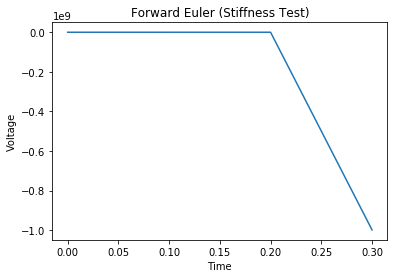

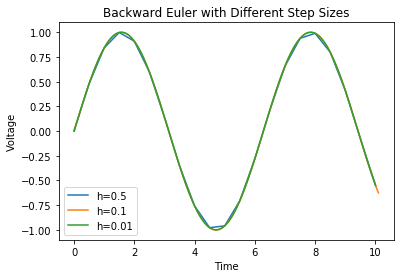

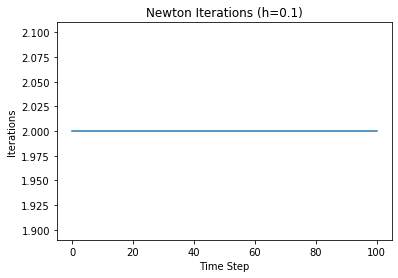

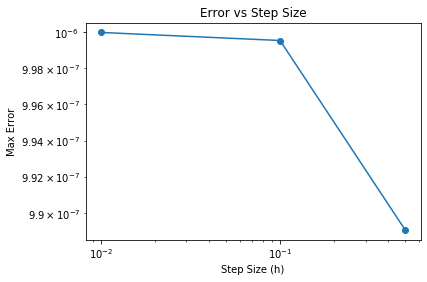

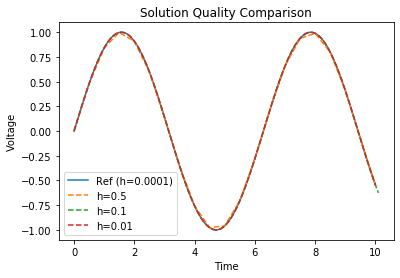

In [16]:
import numpy as np
import matplotlib.pyplot as plt

#Circuit parameters
R = 1000
C = 1e-9
lam = 1/(R*C)

def Vin(t):
    return np.sin(t)

#ODE
def f(t, V):
    return -lam * V + lam * Vin(t)

def euler_forward(f, t0, V0, h, t_end):
    t_values = [t0]
    V_values = [V0]
    
    t = t0
    V = V0
    
    while t < t_end:
        V = V + h * f(t, V)
        t = t + h
        
        #Break loop if the values explode
        if abs(V) > 1e10:
            print("Forward euler is unstable")
            break
        
        t_values.append(t)
        V_values.append(V)
    
    return np.array(t_values), np.array(V_values)

#Residual and derivative for newton
def residual(V_new, V_old, t_new, h):
    return V_new - V_old - h * (-lam * V_new + lam * Vin(t_new))

def residual_derivative(h):
    return 1 + h *lam

def newton_solver(V_old, t_new, h, tol=1e-6, max_iter=20):
    V_guess = V_old
    
    for i in range(max_iter):
        R_val = residual(V_guess, V_old, t_new, h) 
        dR = residual_derivative(h)
        
        V_new = V_guess - R_val / dR
        
        if abs(V_new - V_guess) < tol:
            return V_new, i+1
        
        V_guess = V_new
    
    return V_guess, max_iter

def euler_backward(t0, V0, h, t_end):
    t_values = [t0]
    V_values = [V0]
    iterations = []
    
    t = t0
    V = V0
    
    while t < t_end:
        t_new = t + h
        V_new, iters = newton_solver(V, t_new, h)
        
        t_values.append(t_new)
        V_values.append(V_new)
        iterations.append(iters)
        
        t = t_new
        V = V_new
    
    return np.array(t_values), np.array(V_values), iterations


t0 = 0
V0 = 0
t_end = 10

#Forward euler
t_f, V_f = euler_forward(f, t0, V0, 0.1, t_end)

#Backward euler with different step sizes
step_sizes = [0.5, 0.1, 0.01]
solutions = {}

for h in step_sizes:
    t_b, V_b, iters = euler_backward(t0, V0, h, t_end)
    solutions[h] = (t_b, V_b, iters)

#Get reference solution using tiny step size
t_ref, V_ref, _ = euler_backward(t0, V0, 1e-4, t_end)

#Plot 1: Stiffness test
plt.figure()
plt.plot(t_f, V_f)
plt.title("Forward Euler (Stiffness Test)")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.show()

#Plot 2: Backward euler variations
plt.figure()
for h in step_sizes:
    t_b, V_b, _ = solutions[h]
    plt.plot(t_b, V_b, label=f"h={h}")
plt.title("Backward Euler with Different Step Sizes")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.legend()
plt.show()

#Plot 3: Newton iterations
plt.figure()
_, _, iters = solutions[0.1]
plt.plot(iters)
plt.title("Newton Iterations (h=0.1)")
plt.xlabel("Time Step")
plt.ylabel("Iterations")
plt.show()

#Plot 4: Error calculation
errors = []

for h in step_sizes:
    t_b, V_b, _ = solutions[h]
    err = np.max(np.abs(V_b - np.sin(t_b)))
    errors.append(err)

plt.figure()
plt.loglog(step_sizes, errors, marker='o')
plt.title("Error vs Step Size")
plt.xlabel("Step Size (h)")
plt.ylabel("Max Error")
plt.show()

#Plot 5: Comparison
plt.figure()
plt.plot(t_ref, V_ref, label="Ref (h=0.0001)")
for h in step_sizes:
    t_b, V_b, _ = solutions[h]
    plt.plot(t_b, V_b, '--', label=f"h={h}")
plt.title("Solution Quality Comparison")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.legend()
plt.show()

**Section 1: Introduction & System Selection**

In this project, a stiff ordinary differential equation (ODE) arising from an RC circuit with a fast transient response is analyzed. The voltage across the capacitor in a simple RC circuit is governed by the differential equation,

dV/dt=1/RC(Vin(t)-V)

which relates the rate of change of the capacitor voltage to the difference between the input voltage and the current capacitor voltage.

The circuit's parameters are selected as R = 1000Ω and C = 1nF = 10^-9F. Subsituting these values into the time constant λ = 1/RC gives: 

λ=1/RC=10^6

After this substitution, the governing equation simplifies to: 
dV/dt=-λV+λsin(t)

This system is stiff because the circuit responds changes on in microseconds due to the large value of λ, while the input signal changes slower in seconds. The seperation of time scales on the order 10^6 makes explicit methods more inefficient and unstable.

**Section 2: Demonstration of Stiffness**

To show the stiffness of the system, Euler’s Forward method was applied using a large step size of h=0.1. This method produces unstable solutions that quickly diverge because it can't resolve the fast dynamics of the system.
The stability condition for Euler Forward requires the time step h<2/λ

λ=10^6 was substituted, giving: h < 2 x 10^-6

To simulate up to t=10, 10/(2 x 10^-6)=5 x 10^6 steps were used, which is impractical for explicit integration

The system is considered stiff because the numerical stability constraint forces the step size to be much smaller than what is needed for accuracy.

**Section 3: Mathematical Setup**

To get past the stability limitations of explicit methods, the implicit Backward Euler method was used. This method evaluates the system at the future time step and is defined as:

V_n+1=V_n+hf(t_n+1, V_n+1)

Because the right side depends on the unknown value V_n+1, this results in a nonlinear equation that needs to be solved at each time step. To do this, the residual function used is:
R(V_n+1)=V_n+1-V_n-h(-λV_n+1+λsin(t_n+1)

The Newton-Raphson method is then used to solve this equation. The derivative of the residual is: R'(V_n+1)=1+hλ

This simplifies the iterative update process. The Newton iteration formula is now written as:
V^k+1=V^k-R(V^k)/R'(V^k)

**Section 4: Implementation**

The numerical implementation has several components that work together to solve and analyze the system. First, a function is defined to represent the differential equation governing the RC circuit dynamics.

Next, Euler's Forward is implemented to show instability when applied to stiff systems. This acts as a baseline comparison to show the limitations of explicit methods.

To support the implicit solver, both the residual function and its derivative are used so that Newton–Raphson iteration can be applied efficiently at each time step.

The Backward Euler method is then implemented, where each time step requires solving a nonlinear equation using Newton’s method. Multiple step sizes are tested to evaluate how stability and accuracy change.

**Section 5: Results & Analysis**

The results show the contrast between explicit and implicit methods. Euler Forward becomes unstable even at moderate step sizes because of the stiffness of the system.

On the other hand, Euler Backward remains stable even when relatively large time steps are used. This stability comes at the cost of solving a nonlinear equation at each step, but Newton–Raphson convergence is fast because the system is effectively linear in the unknown variable.

Step sizes tested:

-h=0.5
-h=0.1
-h=0.01

Observations:

-Larger h was faster but less accurate.
-Smaller h was more accurate, and closer to the reference solution.

Reference solution used:h=10^−4.

**Section 6: Performance Analysis**

A performance comparison between the two numerical methods shows a trade-off between simple and stable. Euler Forward requires a step size on the order of h=10^−6 to remain stable, which makes it inefficient for long simulations.

On the other hand, Euler Backward remains stable for much larger step sizes,  reducing the number of required time steps. This advantage comes with the added step of solving a nonlinear equation at every step.

Despite this, the Newton–Raphson method converges quickly, meaning the implicit approach is still computationally efficient for stiff systems overall.

The error analysis shows that reducing the step size consistently improves accuracy, and the convergence behavior aligns with theoretical expectations for first-order methods.

**Section 7: Conclusions**

This system shows that the RC circuit model exhibits stiffness due to extreme separation between electrical time scales. Explicit methods like as Euler's Forward are not the right choice because they require impractically small time steps to remain stable.

In contrast, implicit methods like as Euler Backward give stable solutions even for large step sizes, making them much more practical for stiff systems. The use of Newton–Raphson iteration further improves efficiency by allowing fast convergence when solving the implicit equations.

This part of the project highlights that numerical methods for stiff systems need to be selected with care, an in some cases, the stability requirement might dominate the accuracy requirements when picking a solver.